In [19]:
# Import packages
import re
from pathlib import Path
import statistics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [20]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("Imports loaded")

Imports loaded


In [21]:
BASELINE_DIR = Path('/Users/annliang/Documents/breezeblogs_rust/comparison_results/baseline_results')
SESAME_DIR = Path('/Users/annliang/Documents/breezeblogs_rust/comparison_results/sesame_results')

print(f"Baseline directory: {BASELINE_DIR.absolute()}")
print(f"Sesame directory: {SESAME_DIR.absolute()}")
print()

# Check directories exist
if not BASELINE_DIR.exists():
    print(f"WARNING: {BASELINE_DIR} does not exist!")
    print(f"Create it or update BASELINE_DIR path")
    
if not SESAME_DIR.exists():
    print(f"WARNING: {SESAME_DIR} does not exist!")
    print(f"Create it or update SESAME_DIR path")

Baseline directory: /Users/annliang/Documents/breezeblogs_rust/comparison_results/baseline_results
Sesame directory: /Users/annliang/Documents/breezeblogs_rust/comparison_results/sesame_results



In [22]:
def convert_to_ms(value, unit):
    """Convert time value to milliseconds"""
    unit = unit.lower()
    if unit == 'us':
        return value / 1000
    elif unit == 'ms':
        return value
    elif unit == 's':
        return value * 1000
    elif unit == 'm':
        return value * 60000
    return value

def parse_wrk_output(filepath):
    """Parse wrk text output"""
    try:
        with open(filepath, 'r') as f:
            content = f.read()
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return {}
    
    metrics = {}
    
    # Check for connection errors
    if 'Connection refused' in content or 'unable to connect' in content:
        print(f"{filepath.name}: Connection refused (server likely crashed)")
        return {'error': 'connection_refused'}
    
    # Extract latency stats
    latency_match = re.search(r'Latency\s+(\d+\.\d+)(\w+)\s+(\d+\.\d+)(\w+)\s+(\d+\.\d+)(\w+)', content)
    if latency_match:
        avg, avg_unit = latency_match.group(1), latency_match.group(2)
        stdev, stdev_unit = latency_match.group(3), latency_match.group(4)
        max_val, max_unit = latency_match.group(5), latency_match.group(6)
        
        metrics['avg_latency_ms'] = convert_to_ms(float(avg), avg_unit)
        metrics['stdev_latency_ms'] = convert_to_ms(float(stdev), stdev_unit)
        metrics['max_latency_ms'] = convert_to_ms(float(max_val), max_unit)
    
    # Extract requests/sec
    req_sec_match = re.search(r'Requests/sec:\s+(\d+\.\d+)', content)
    if req_sec_match:
        metrics['requests_per_sec'] = float(req_sec_match.group(1))
    
    # Extract total requests
    total_match = re.search(r'(\d+)\s+requests in', content)
    if total_match:
        metrics['total_requests'] = int(total_match.group(1))
    
    # Extract percentiles
    p50_match = re.search(r'50%\s+(\d+\.\d+)(\w+)', content)
    p75_match = re.search(r'75%\s+(\d+\.\d+)(\w+)', content)
    p90_match = re.search(r'90%\s+(\d+\.\d+)(\w+)', content)
    p99_match = re.search(r'99%\s+(\d+\.\d+)(\w+)', content)
    
    if p50_match:
        metrics['p50_latency_ms'] = convert_to_ms(float(p50_match.group(1)), p50_match.group(2))
    if p75_match:
        metrics['p75_latency_ms'] = convert_to_ms(float(p75_match.group(1)), p75_match.group(2))
    if p90_match:
        metrics['p90_latency_ms'] = convert_to_ms(float(p90_match.group(1)), p90_match.group(2))
    if p99_match:
        metrics['p99_latency_ms'] = convert_to_ms(float(p99_match.group(1)), p99_match.group(2))
    
    return metrics

print("Parse functions defined")

Parse functions defined


In [23]:
print("Loading baseline results...")
baseline_files = list(BASELINE_DIR.glob('*.txt'))
print(f"  Found {len(baseline_files)} files")

print("Loading Sesame results...")
sesame_files = list(SESAME_DIR.glob('*.txt'))
print(f"  Found {len(sesame_files)} files")

if not baseline_files and not sesame_files:
    print("\nNo result files found!")
    print(f"   Check that files exist in:")
    print(f"   - {BASELINE_DIR.absolute()}")
    print(f"   - {SESAME_DIR.absolute()}")
else:
    print(f"\nFound results from both versions")

# Parse baseline
baseline_data = {}
for f in baseline_files:
    # Remove any prefix (baseline_, sesame_) to get just the endpoint name
    endpoint = f.stem.replace('baseline_', '').replace('sesame_', '')
    metrics = parse_wrk_output(f)
    if metrics and 'error' not in metrics:
        baseline_data[endpoint] = metrics

# Parse Sesame
sesame_data = {}
for f in sesame_files:
    endpoint = f.stem.replace('baseline_', '').replace('sesame_', '')
    metrics = parse_wrk_output(f)
    if metrics and 'error' not in metrics:
        sesame_data[endpoint] = metrics

print(f"\nParsed {len(baseline_data)} baseline endpoints")
print(f"Parsed {len(sesame_data)} Sesame endpoints")

# Show what we have
print("\nBaseline endpoints:", sorted(baseline_data.keys()))
print("Sesame endpoints:", sorted(sesame_data.keys()))

Loading baseline results...
  Found 10 files
Loading Sesame results...
  Found 10 files

Found results from both versions

Parsed 9 baseline endpoints
Parsed 9 Sesame endpoints

Baseline endpoints: ['get_blog_posts', 'get_interests', 'login', 'logout', 'register', 'send_news_mails', 'session', 'set_email', 'set_interests']
Sesame endpoints: ['get_blog_posts', 'get_interests', 'login', 'logout', 'register', 'send_news_mails', 'session', 'set_email', 'set_interests']


In [24]:
comparison = []

all_endpoints = sorted(set(baseline_data.keys()) | set(sesame_data.keys()))

for endpoint in all_endpoints:
    row = {'endpoint': endpoint}
    
    if endpoint in baseline_data:
        b = baseline_data[endpoint]
        row['baseline_avg_ms'] = b.get('avg_latency_ms', 0)
        row['baseline_p99_ms'] = b.get('p99_latency_ms', 0)
        row['baseline_req_sec'] = b.get('requests_per_sec', 0)
    else:
        row['baseline_avg_ms'] = None
        row['baseline_p99_ms'] = None
        row['baseline_req_sec'] = None
    
    if endpoint in sesame_data:
        s = sesame_data[endpoint]
        row['sesame_avg_ms'] = s.get('avg_latency_ms', 0)
        row['sesame_p99_ms'] = s.get('p99_latency_ms', 0)
        row['sesame_req_sec'] = s.get('requests_per_sec', 0)
    else:
        row['sesame_avg_ms'] = None
        row['sesame_p99_ms'] = None
        row['sesame_req_sec'] = None
    
    # Calculate overhead (only if both exist)
    if endpoint in baseline_data and endpoint in sesame_data:
        b = baseline_data[endpoint]
        s = sesame_data[endpoint]
        
        b_avg = b.get('avg_latency_ms', 0)
        s_avg = s.get('avg_latency_ms', 0)
        b_req = b.get('requests_per_sec', 0)
        s_req = s.get('requests_per_sec', 0)
        
        if b_avg > 0:
            row['avg_overhead_%'] = ((s_avg - b_avg) / b_avg * 100)
        if b_req > 0:
            row['throughput_change_%'] = ((s_req - b_req) / b_req * 100)
    
    comparison.append(row)

df = pd.DataFrame(comparison)

print("\n" + "="*80)
print("COMPARISON TABLE")
print("="*80)
print(df.to_string(index=False))
print()


COMPARISON TABLE
       endpoint  baseline_avg_ms  baseline_p99_ms  baseline_req_sec  sesame_avg_ms  sesame_p99_ms  sesame_req_sec  avg_overhead_%  throughput_change_%
 get_blog_posts          0.52624             1.22           1114.90           5.43          15.90          892.87      931.848586           -19.914791
  get_interests         15.07000            36.01           1389.88          15.93          49.49         1298.96        5.706702            -6.541572
          login       1310.00000          1990.00             42.49        1480.00        2000.00           38.41       12.977099            -9.602259
         logout          1.03000             3.41          90888.49           1.03           3.42        82891.90        0.000000            -8.798243
       register       1320.00000          1980.00             41.10        1430.00        1980.00           40.96        8.333333            -0.340633
send_news_mails          9.26000            20.14            884.43         

In [25]:
if 'avg_overhead_%' in df.columns and df['avg_overhead_%'].notna().any():
    overhead_values = df['avg_overhead_%'].dropna()
    throughput_values = df['throughput_change_%'].dropna()
    
    print("="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    print(f"Average Latency Overhead:    {overhead_values.mean():>+7.1f}%")
    print(f"  - Minimum:                 {overhead_values.min():>+7.1f}%")
    print(f"  - Maximum:                 {overhead_values.max():>+7.1f}%")
    print(f"  - Median:                  {overhead_values.median():>+7.1f}%")
    print(f"  - Std Dev:                 {overhead_values.std():>7.1f}%")
    print()
    print(f"Average Throughput Change:   {throughput_values.mean():>+7.1f}%")
    print(f"  - Minimum:                 {throughput_values.min():>+7.1f}%")
    print(f"  - Maximum:                 {throughput_values.max():>+7.1f}%")
    print(f"  - Median:                  {throughput_values.median():>+7.1f}%")
    print()
    
    # Count endpoints tested
    both_tested = len(df[(df['baseline_avg_ms'].notna()) & (df['sesame_avg_ms'].notna())])
    only_baseline = len(df[(df['baseline_avg_ms'].notna()) & (df['sesame_avg_ms'].isna())])
    only_sesame = len(df[(df['baseline_avg_ms'].isna()) & (df['sesame_avg_ms'].notna())])
    
    print(f"Endpoints tested in both:    {both_tested}")
    print(f"Only in baseline:            {only_baseline}")
    print(f"Only in Sesame:              {only_sesame}")
    print("="*80)
else:
    print("\nCannot calculate overhead - missing data from one or both versions")

SUMMARY STATISTICS
Average Latency Overhead:     +132.8%
  - Minimum:                   -81.8%
  - Maximum:                  +931.8%
  - Median:                     +8.3%
  - Std Dev:                   316.6%

Average Throughput Change:      -7.0%
  - Minimum:                   -19.9%
  - Maximum:                    -0.3%
  - Median:                     -6.5%

Endpoints tested in both:    9
Only in baseline:            0
Only in Sesame:              0



Visualization saved as 'performance_comparison.png'


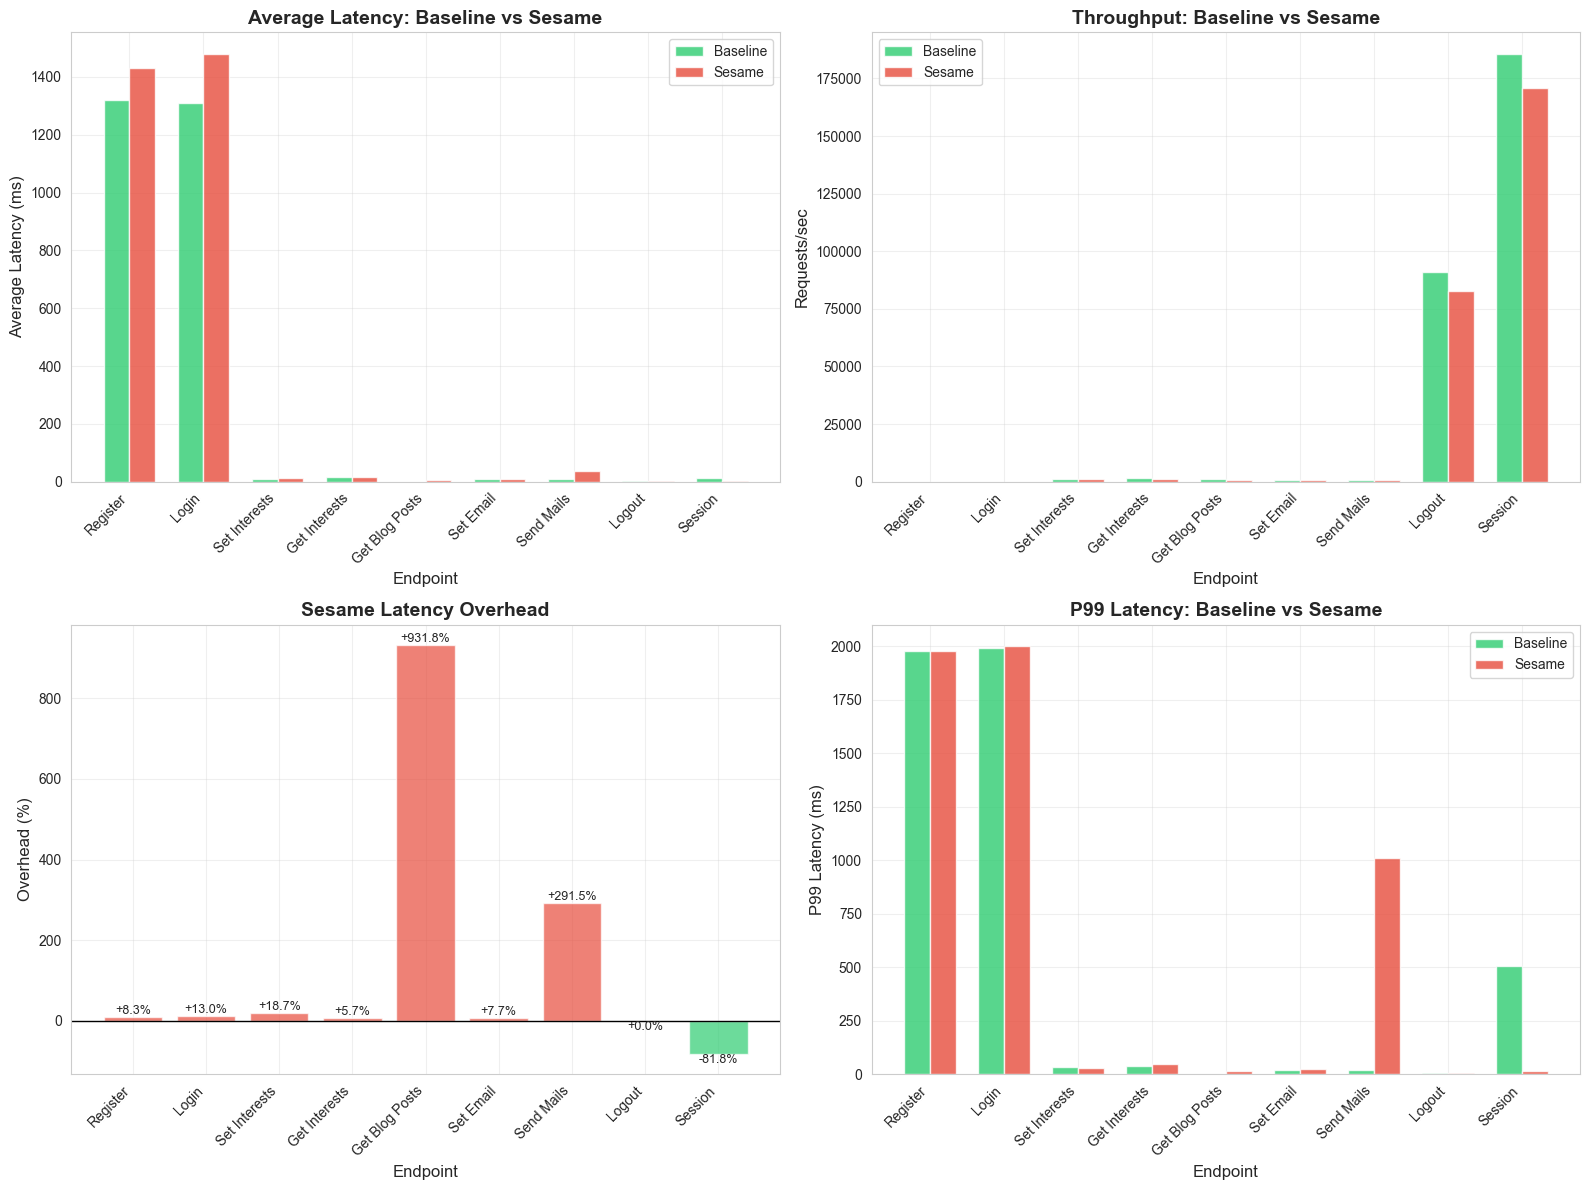

In [26]:
# Cell 7: Visualizations with Sorted Endpoints

df_complete = df[(df['baseline_avg_ms'].notna()) & (df['sesame_avg_ms'].notna())].copy()

if len(df_complete) == 0:
    print("No complete data pairs to visualize")
    print("   Need endpoints tested in BOTH baseline and Sesame")
else:
    # Define custom order for endpoints
    endpoint_order = [
        'register',
        'login',
        'set_interests',      # POST interests
        'get_interests',      # GET interests
        'get_blog_posts',
        'set_email',
        'send_news_mails',
        'logout',
        'session'
    ]
    
    # Sort dataframe by custom order
    # Create a mapping for sorting
    order_map = {ep: i for i, ep in enumerate(endpoint_order)}
    df_complete['sort_order'] = df_complete['endpoint'].map(order_map)
    df_complete = df_complete.sort_values('sort_order')
    
    # Clean up endpoint names for display
    endpoint_display_names = {
        'register': 'Register',
        'login': 'Login',
        'set_interests': 'Set Interests',
        'get_interests': 'Get Interests',
        'get_blog_posts': 'Get Blog Posts',
        'set_email': 'Set Email',
        'send_news_mails': 'Send Mails',
        'logout': 'Logout',
        'session': 'Session'
    }
    
    endpoints = df_complete['endpoint'].values
    display_names = [endpoint_display_names.get(ep, ep) for ep in endpoints]
    x = range(len(endpoints))
    width = 0.35
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Average Latency Comparison
    ax1 = axes[0, 0]
    ax1.bar([i - width/2 for i in x], df_complete['baseline_avg_ms'], width, 
            label='Baseline', alpha=0.8, color='#2ecc71')
    ax1.bar([i + width/2 for i in x], df_complete['sesame_avg_ms'], width, 
            label='Sesame', alpha=0.8, color='#e74c3c')
    ax1.set_xlabel('Endpoint', fontsize=12)
    ax1.set_ylabel('Average Latency (ms)', fontsize=12)
    ax1.set_title('Average Latency: Baseline vs Sesame', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(display_names, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Throughput Comparison
    ax2 = axes[0, 1]
    ax2.bar([i - width/2 for i in x], df_complete['baseline_req_sec'], width, 
            label='Baseline', alpha=0.8, color='#2ecc71')
    ax2.bar([i + width/2 for i in x], df_complete['sesame_req_sec'], width, 
            label='Sesame', alpha=0.8, color='#e74c3c')
    ax2.set_xlabel('Endpoint', fontsize=12)
    ax2.set_ylabel('Requests/sec', fontsize=12)
    ax2.set_title('Throughput: Baseline vs Sesame', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(display_names, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Overhead Percentage
    if 'avg_overhead_%' in df_complete.columns:
        ax3 = axes[1, 0]
        colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in df_complete['avg_overhead_%']]
        bars = ax3.bar(x, df_complete['avg_overhead_%'], color=colors, alpha=0.7)
        ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax3.set_xlabel('Endpoint', fontsize=12)
        ax3.set_ylabel('Overhead (%)', fontsize=12)
        ax3.set_title('Sesame Latency Overhead', fontsize=14, fontweight='bold')
        ax3.set_xticks(x)
        ax3.set_xticklabels(display_names, rotation=45, ha='right')
        ax3.grid(True, alpha=0.3)
        
        # Add percentage labels on bars 
        for i, (bar, val) in enumerate(zip(bars, df_complete['avg_overhead_%'])):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:+.1f}%',
                    ha='center', va='bottom' if height > 0 else 'top',
                    fontsize=9)
    
    # Plot 4: P99 Latency
    ax4 = axes[1, 1]
    ax4.bar([i - width/2 for i in x], df_complete['baseline_p99_ms'], width, 
            label='Baseline', alpha=0.8, color='#2ecc71')
    ax4.bar([i + width/2 for i in x], df_complete['sesame_p99_ms'], width, 
            label='Sesame', alpha=0.8, color='#e74c3c')
    ax4.set_xlabel('Endpoint', fontsize=12)
    ax4.set_ylabel('P99 Latency (ms)', fontsize=12)
    ax4.set_title('P99 Latency: Baseline vs Sesame', fontsize=14, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(display_names, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
    print("\nVisualization saved as 'performance_comparison.png'")
    plt.show()

GDPR paper-style comparison saved!


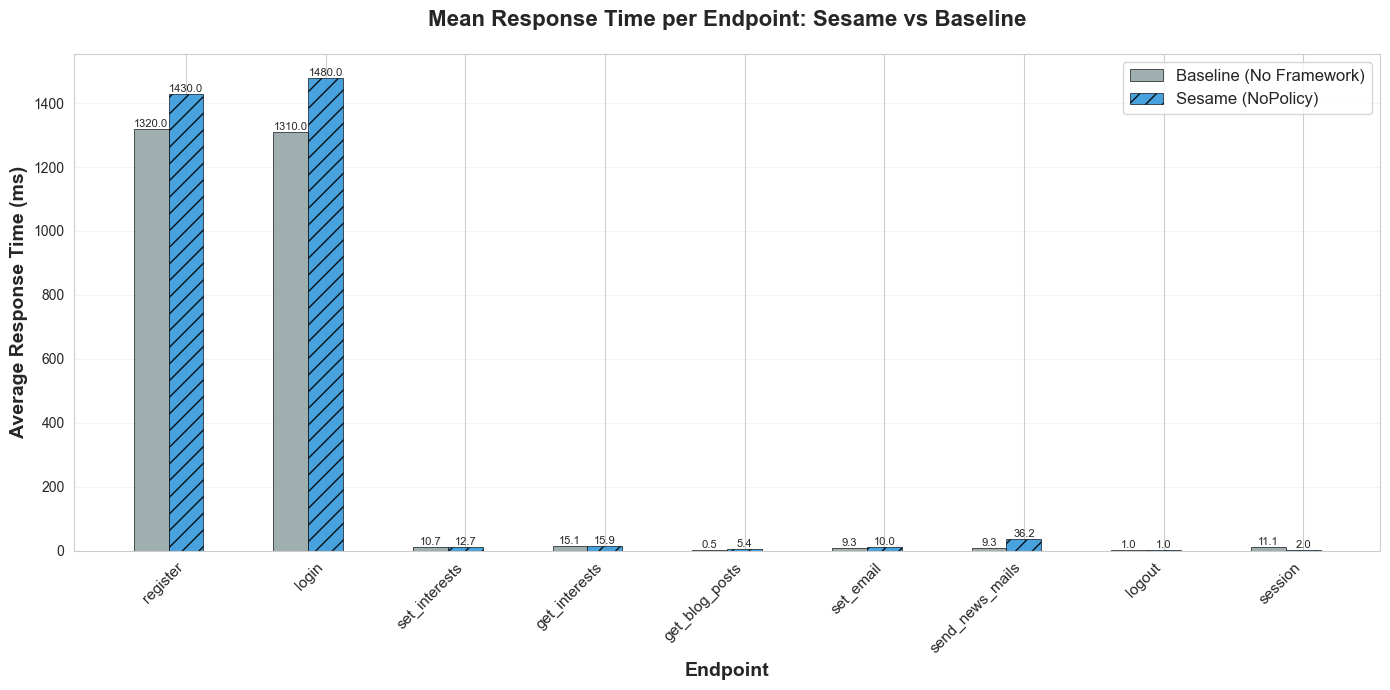

In [28]:
# GDPR Paper Style Comparison (similar to Figure 4)

fig, ax = plt.subplots(figsize=(14, 7))

# Your data
endpoints = df_complete['endpoint'].values
x_pos = np.arange(len(endpoints))
width = 0.25

# Baseline and Sesame bars
bars1 = ax.bar(x_pos - width, df_complete['baseline_avg_ms'], width, 
               label='Baseline (No Framework)', alpha=0.9, color='#95a5a6', 
               edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x_pos, df_complete['sesame_avg_ms'], width, 
               label='Sesame (NoPolicy)', alpha=0.9, color='#3498db',
               edgecolor='black', linewidth=0.5, hatch='//')

ax.set_xlabel('Endpoint', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Response Time (ms)', fontsize=14, fontweight='bold')
ax.set_title('Mean Response Time per Endpoint: Sesame vs Baseline', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(endpoints, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.2, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('gdpr_paper_style_comparison.png', dpi=300, bbox_inches='tight')
print("GDPR paper-style comparison saved!")
plt.show()